/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:438: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker (7).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)
/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:438: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)
/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:438: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  points = ax.scatter(x=x, y=y, **kws)
/usr/local/lib/python3.10/dist-packages/seaborn/relational.py:438: UserWarning: You passed a edgecolor/edgec

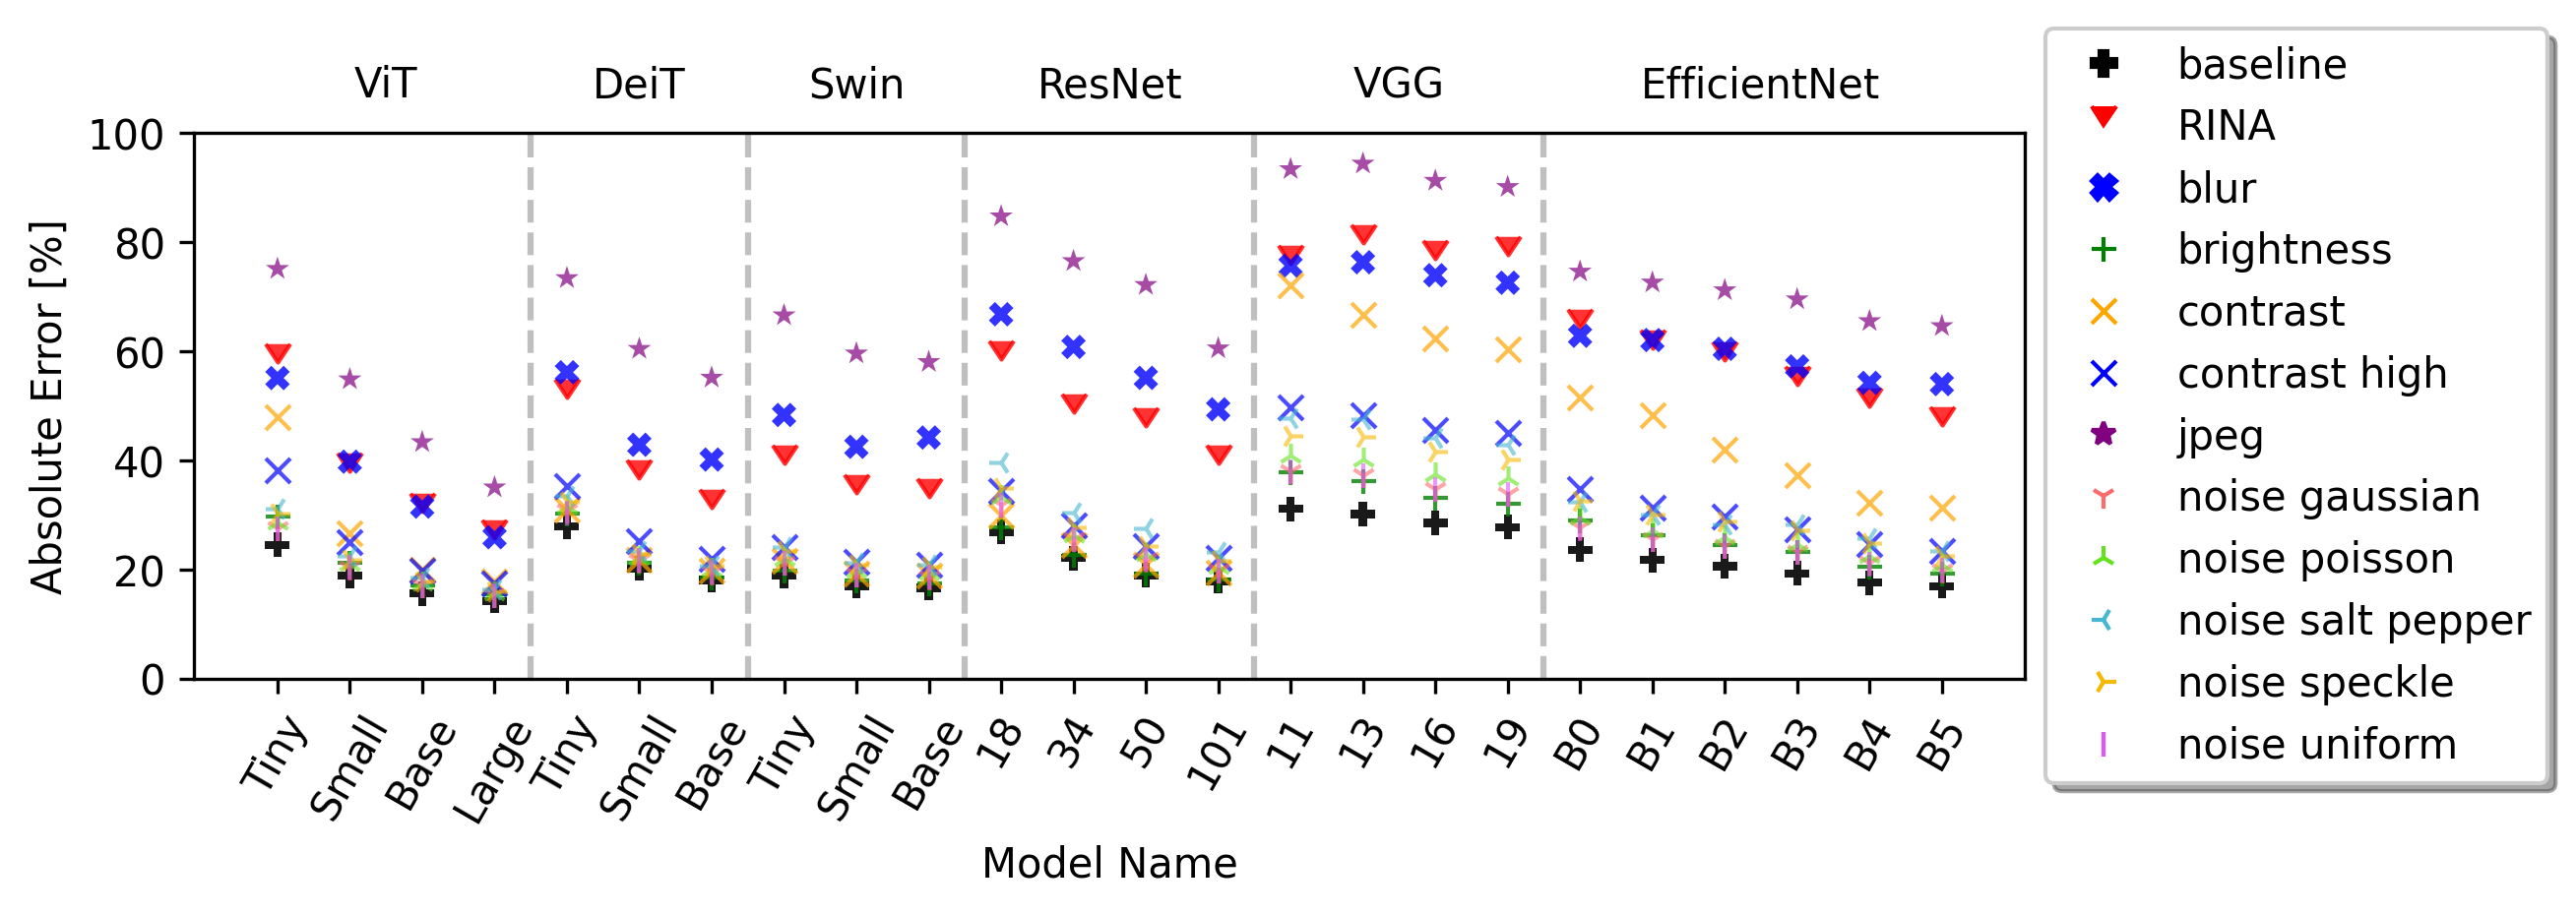

In [ ]:
import re
import enum
import dataclasses
from typing import Dict, List, Tuple
import dataclasses


import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["patch.force_edgecolor"] = False


# -----------------------------
# 1) Inputs (only edit this list)
# -----------------------------
class Attack(enum.Enum):
    BASELINE = "baseline"
    AGS = "AGS"
    BIA = "BIA"
    HIT = "HIT"
    RINA = "RINA"
    BLUR = "blur"
    BRIGHTNESS="brightness"
    CONTRAST="contrast"
    CONTRAST_HIGH="contrast high"
    GAMMA="gamma"
    JPEG = "jpeg"
    NOISE_GAUSSIAN="noise gaussian"
    NOISE_POISSON="noise poisson"
    NOISE_SALT_PEPPER="noise salt pepper"
    NOISE_SPECKLE="noise speckle"
    NOISE_UNIFORM="noise uniform"

@dataclasses.dataclass
class PlotConfig:
    marker: str
    label: str
    attack_key: Attack
    color: str = None
    alpha: float = 1.0



@dataclasses.dataclass(frozen=True)
class DataFile:
    alpha: float
    filename: str
    attack: Attack
    ssim: float
    plot_config: PlotConfig = None


files = [
    # DataFile(alpha=0.85, filename="eval_adversarial-0.85_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.70, plot_config=PlotConfig(marker=7, label="ours", attack_key=Attack.RINA)),
    # DataFile(alpha=1.00, filename="eval_adversarial-1.0_tag-emuzc-reflect.csv",  attack=Attack.RINA, ssim=0.63, plot_config=PlotConfig(marker=7, label="ours", attack_key=Attack.RINA)),
    # DataFile(alpha=1.15, filename="eval_adversarial-1.15_tag-emuzc-reflect.csv", attack=Attack.RINA, ssim=0.56, plot_config=PlotConfig(marker=7, label="ours", attack_key=Attack.RINA, color="red", alpha=0.8)),

    # DataFile(alpha=1.00, filename="eval_adversarial-x.x_tag-HIT.csv", attack=Attack.HIT, ssim=0.56001, plot_config=PlotConfig(marker=".", label="HIT", attack_key=Attack.HIT)),
    DataFile(alpha=0.00, filename="eval_emuzc_resnet50_fmqt-mobilenetv3/eval_adversarial-0.0_tag-emuzc.csv",
             attack=Attack.BASELINE, ssim=1.0, plot_config=PlotConfig(marker="P", label="baseline", attack_key=Attack.BASELINE, color="black", alpha=0.9)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/blur.csv", attack=Attack.BLUR, ssim=0.57, plot_config=PlotConfig(marker="x", label="blur", attack_key=Attack.BLUR)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/brightness.csv", attack=Attack.BRIGHTNESS, ssim=0.57, plot_config=PlotConfig(marker=".", label="brightness", attack_key=Attack.BRIGHTNESS)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/contrast.csv", attack=Attack.CONTRAST, ssim=0.57, plot_config=PlotConfig(marker="p", label="contrast", attack_key=Attack.CONTRAST)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/gamma.csv", attack=Attack.GAMMA, ssim=0.57, plot_config=PlotConfig(marker="s", label="gamma", attack_key=Attack.GAMMA)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/jpeg.csv", attack=Attack.JPEG, ssim=0.57, plot_config=PlotConfig(marker="8", label="jpeg", attack_key=Attack.JPEG)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/noise_gaussian.csv", attack=Attack.NOISE_GAUSSIAN, ssim=0.57, plot_config=PlotConfig(marker="+", label="noise_gaussian", attack_key=Attack.NOISE_GAUSSIAN)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/noise_poisson.csv", attack=Attack.NOISE_POISSON, ssim=0.57, plot_config=PlotConfig(marker="_", label="noise_poisson", attack_key=Attack.NOISE_POISSON)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/noise_salt_pepper.csv", attack=Attack.NOISE_SALT_PEPPER, ssim=0.57, plot_config=PlotConfig(marker="D", label="noise_salt_pepper", attack_key=Attack.NOISE_SALT_PEPPER)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/noise_speckle.csv", attack=Attack.NOISE_SPECKLE, ssim=0.57, plot_config=PlotConfig(marker="d", label="noise_speckle", attack_key=Attack.NOISE_SPECKLE)),
    # DataFile(alpha=1.00, filename="./val_primitive_0.52_color/noise_uniform.csv", attack=Attack.NOISE_UNIFORM, ssim=0.57, plot_config=PlotConfig(marker="X", label="noise_uniform", attack_key=Attack.NOISE_UNIFORM)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/blur.csv", attack=Attack.BLUR, ssim=0.52, plot_config=PlotConfig(marker="X", label="blur", attack_key=Attack.BLUR, color="blue", alpha=0.8)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/brightness.csv", attack=Attack.BRIGHTNESS, ssim=0.52, plot_config=PlotConfig(marker="+", label="brightness", attack_key=Attack.BRIGHTNESS, color="green", alpha=0.8)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/contrast.csv", attack=Attack.CONTRAST, ssim=0.52, plot_config=PlotConfig(marker="x", label="contrast", attack_key=Attack.CONTRAST, color="orange", alpha=0.7)),
    DataFile(alpha=1.00, filename="tmp/contrast.csv", attack=Attack.CONTRAST_HIGH, ssim=0.52, plot_config=PlotConfig(marker="x", label="contrast high", attack_key=Attack.CONTRAST, color="blue", alpha=0.7)),
    # DataFile(alpha=1.00, filename="val_resized/gamma.csv", attack=Attack.GAMMA, ssim=0.57, plot_config=PlotConfig(marker="s", label="gamma", attack_key=Attack.GAMMA)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/jpeg.csv", attack=Attack.JPEG, ssim=0.52, plot_config=PlotConfig(marker="*", label="jpeg", attack_key=Attack.JPEG, color="purple", alpha=0.7)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/noise_gaussian.csv", attack=Attack.NOISE_GAUSSIAN, ssim=0.52, plot_config=PlotConfig(marker="1", label="noise_gaussian", attack_key=Attack.NOISE_GAUSSIAN, color="#FF6B6B", alpha=0.6)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/noise_poisson.csv", attack=Attack.NOISE_POISSON, ssim=0.52, plot_config=PlotConfig(marker="2", label="noise_poisson", attack_key=Attack.NOISE_POISSON, color="#62E31D", alpha=0.6)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/noise_salt_pepper.csv", attack=Attack.NOISE_SALT_PEPPER, ssim=0.52, plot_config=PlotConfig(marker="3", label="noise_salt_pepper", attack_key=Attack.NOISE_SALT_PEPPER, color="#45B7D1", alpha=0.6)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/noise_speckle.csv", attack=Attack.NOISE_SPECKLE, ssim=0.52, plot_config=PlotConfig(marker="4", label="noise_speckle", attack_key=Attack.NOISE_SPECKLE, color="#F7B801", alpha=0.6)),
    DataFile(alpha=1.00, filename="val_primitive_0.52_color/noise_uniform.csv", attack=Attack.NOISE_UNIFORM, ssim=0.52, plot_config=PlotConfig(marker="|", label="noise_uniform", attack_key=Attack.NOISE_UNIFORM, color="#E056FD", alpha=0.6)),
]


# -----------------------------
# 2) Loading + normalization
# -----------------------------
def _model_stem(model: str) -> str:
    # "vit_tiny_patch16_224.augreg2_in21k_ft_in1k" -> "vit_tiny_patch16_224"
    return str(model).split(".")[0]


def load_eval(files: List[DataFile]) -> pd.DataFrame:
    dfs = []
    for f in files:
        d = pd.read_csv(f.filename)
        d["attack"] = f.attack.value
        d["alpha"] = f.alpha
        d["ssim"] = float(f.ssim)
        d["model_name"] = d["model"].map(_model_stem)
        d["plot_marker"] = f.plot_config.marker
        d["plot_label"] = f.plot_config.label
        d["plot_attack_key"] = f.plot_config.attack_key.value
        d["plot_color"] = f.plot_config.color
        d["plot_alpha"] = f.plot_config.alpha
        dfs.append(d)
    if not dfs:
        raise ValueError("No input files.")
    df = pd.concat(dfs, ignore_index=True)

    # Optional: filter out known duplicates if present
    df = df[df["model"] != "vit_base_patch16_224.augreg2_in21k_ft_in1k"].copy()

    # Basic sanity checks for expected columns
    required = {"model", "model_name", "top1_err", "attack", "ssim"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in input CSV(s): {sorted(missing)}")

    return df


# -----------------------------
# 3) Automatic model ordering + labels + family boundaries
# -----------------------------
_FAMILY_ORDER = ["ViT", "DeiT", "Swin", "ResNet", "VGG", "EfficientNet", "Other"]


def _family_of(model_name: str) -> str:
    m = model_name
    if m.startswith("vit_"):
        return "ViT"
    if m.startswith("deit_"):
        return "DeiT"
    if m.startswith("swin_"):
        return "Swin"
    if m.startswith("resnet"):
        return "ResNet"
    if m.startswith("vgg"):
        return "VGG"
    if "efficientnet" in m:
        return "EfficientNet"
    return "Other"


def _within_family_key(model_name: str) -> Tuple:
    fam = _family_of(model_name)

    if fam in {"ViT", "DeiT", "Swin"}:
        # Prefer Tiny < Small < Base < Large if present
        order = {"tiny": 0, "small": 1, "base": 2, "large": 3}
        m = re.search(r"_(tiny|small|base|large)_", model_name)
        return (order.get(m.group(1), 99) if m else 99, model_name)

    if fam == "ResNet":
        m = re.search(r"resnet(\d+)", model_name)
        return (int(m.group(1)) if m else 10**9, model_name)

    if fam == "VGG":
        m = re.search(r"vgg(\d+)", model_name)
        return (int(m.group(1)) if m else 10**9, model_name)

    if fam == "EfficientNet":
        # tf_efficientnet_b0 ... -> B0 < B1 < ...
        m = re.search(r"_b(\d+)", model_name)
        return (int(m.group(1)) if m else 10**9, model_name)

    return (10**9, model_name)


def build_model_axis(df: pd.DataFrame) -> Tuple[List[str], Dict[str, str], List[int], List[str], List[float]]:
    models = sorted(df["model_name"].unique(), key=lambda m: (_FAMILY_ORDER.index(_family_of(m)),) + _within_family_key(m))

    # Short tick labels
    tick_map: Dict[str, str] = {}
    for m in models:
        fam = _family_of(m)
        if fam in {"ViT", "DeiT", "Swin"}:
            mm = re.search(r"_(tiny|small|base|large)_", m)
            tick_map[m] = mm.group(1).capitalize() if mm else m
        elif fam == "ResNet":
            mm = re.search(r"resnet(\d+)", m)
            tick_map[m] = mm.group(1) if mm else m
        elif fam == "VGG":
            mm = re.search(r"vgg(\d+)", m)
            tick_map[m] = mm.group(1) if mm else m
        elif fam == "EfficientNet":
            mm = re.search(r"_b(\d+)", m)
            tick_map[m] = f"B{mm.group(1)}" if mm else m
        else:
            tick_map[m] = m

    # Family boundaries (vertical separators) + label positions
    families = [_family_of(m) for m in models]
    boundaries = []
    family_labels = []
    family_centers = []

    start = 0
    for i in range(1, len(models) + 1):
        if i == len(models) or families[i] != families[start]:
            fam = families[start]
            end = i  # exclusive
            if fam != "Other":
                family_labels.append(fam)
                family_centers.append((start + end - 1) / 2.0)
            boundaries.append(end)  # boundary after this block
            start = i

    # separators at boundaries between families (exclude last)
    separators = [b for b in boundaries[:-1] if b > 0]

    return models, tick_map, separators, family_labels, family_centers


# -----------------------------
# 4) Plot (auto adapts to whatever files you add)
# -----------------------------
def plot_figure(df: pd.DataFrame, figsize=(8, 2.4), dpi=300):

    # Build x-axis categorical ordering
    models, tick_map, separators, fam_labels, fam_centers = build_model_axis(df)
    df = df.copy()
    df["model_name"] = pd.Categorical(df["model_name"], categories=models, ordered=True)

    # Color mapping by SSIM (continuous)
    palette = sns.color_palette("icefire", as_cmap=True).reversed()

    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=dpi)

    handles, labels = [], []
    for attack in Attack:
        df_attack = df[df["attack"] == attack.value]
        if len(df_attack) == 0:
            continue
        marker = df_attack["plot_marker"].iloc[0]
        color = df_attack["plot_color"].iloc[0]
        alpha = df_attack["plot_alpha"].iloc[0]
        label = df_attack["plot_label"].iloc[0]
        
        linewidth = 1
        sns.scatterplot(
            ax=ax, data=df_attack, x="model_name", y="top1_err",
            color=color, alpha=alpha, hue_norm=(0.5, 1.0),
            marker=marker, edgecolor="none", linewidth=linewidth
        )
        # Custom marker legend (HIT/baseline/ours)
        handles.append(
            matplotlib.lines.Line2D([], [], marker=marker, linestyle="None", alpha=1.0, 
                                  color=color, linewidth=linewidth, markeredgewidth=linewidth),
        )
        labels.append(attack.value)


    # Draw in a stable order (others behind, then baseline, then HIT)
    # if len(df_baseline):
    #     sns.scatterplot(
    #         ax=ax, data=df_baseline, x="model_name", y="top1_err",
    #         hue="ssim", palette=palette, hue_norm=(0.5, 1.0),
    #         marker="p", edgecolor="none"
    #     )
    # if len(df_hit):
    #     sns.scatterplot(
    #         ax=ax, data=df_hit, x="model_name", y="top1_err",
    #         hue="ssim", palette=palette, hue_norm=(0.5, 1.0),
    #         marker=".", edgecolor="none"
    #     )
    # if len(df_blur):
    #     sns.scatterplot(
    #         ax=ax, data=df_blur, x="model_name", y="top1_err",
    #         hue="ssim", palette=palette, hue_norm=(0.5, 1.0),
    #         marker="X", edgecolor="none"
    #     )

    # Remove seaborn's automatic legend (we add a custom one + colorbar)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Vertical separators between families
    for idx in separators:
        ax.axvline(x=idx - 0.5, color="gray", linestyle="--", alpha=0.5)

    # Family labels on top
    for fam, center in zip(fam_labels, fam_centers):
        ax.text(center, 1.05, fam, ha="center", va="bottom", transform=ax.get_xaxis_transform())

    # Axis labels/limits
    ax.set_ylabel("Absolute Error [%]")
    ax.set_xlabel("Model Name")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=60)

    # Short tick labels
    ax.set_xticklabels([tick_map[str(t.get_text())] for t in ax.get_xticklabels()])


    ax.legend(
        loc="center left", bbox_to_anchor=(1, 0.5),
        fancybox=True, shadow=True, ncol=1,
        handles=handles, labels=labels
    )

    plt.show()


df = load_eval(files)
plot_figure(df)


In [31]:
df["family"] = df["model_name"].map(_family_of)
# Assuming your grouped dataframe is called grouped_df
grouped_df = df.groupby(["attack", "family"]).agg({"top1_err": ["mean", "std"]})

# Extract baseline values (indexed by family)
baseline = grouped_df.xs('baseline', level='attack')

# Subtract baseline from all attacks for each family
diff_from_baseline = grouped_df.sub(baseline, level='family')
pct_change_from_baseline = ((grouped_df - baseline) / baseline) * 100
pct_change_sorted = (
    pct_change_from_baseline
    .groupby(level='attack', group_keys=False)
    .apply(lambda x: x.sort_values(by=('top1_err', 'mean')))
)
# Optional: Remove baseline rows since they'll be all zeros
# diff_from_baseline = diff_from_baseline.drop('baseline', level='attack')

# print(diff_from_baseline)
print(pct_change_sorted)

# # Generate LaTeX table from the sorted percentage change dataframe
# latex_table = pct_change_sorted.to_latex(
#     float_format="%.0f",
#     caption="Percentage change in top-1 error from baseline by attack type and model family",
#     label="tab:pct_change",
#     escape=False
# )

# print(latex_table)

# Get unique attacks
attacks = pct_change_sorted.index.get_level_values('attack').unique()
mid_point = len(attacks) // 2

# Split into two groups of attacks
first_half_attacks = attacks[:mid_point]
second_half_attacks = attacks[mid_point:]

# Create two separate dataframes
df_left = pct_change_sorted.loc[first_half_attacks]
df_right = pct_change_sorted.loc[second_half_attacks]

# Convert each to LaTeX without table environment
latex_left = df_left.to_latex(float_format="%.0f", escape=False, index=True)
latex_right = df_right.to_latex(float_format="%.0f", escape=False, index=True)

# Combine into two-column layout
latex_two_columns = f"""\\begin{{table}}[htbp]
\\centering
\\small
\\caption{{Percentage change in top-1 error from baseline by attack type and model family}}
\\label{{tab:pct_change}}
\\begin{{minipage}}{{0.48\\textwidth}}
\\centering
{latex_right}
\\end{{minipage}}
\\hfill
\\begin{{minipage}}{{0.48\\textwidth}}
\\centering
{latex_left}
\\end{{minipage}}
\\end{{table}}"""

print(latex_two_columns)

                                  top1_err            
                                      mean         std
attack            family                              
baseline          DeiT            0.000000    0.000000
                  EfficientNet    0.000000    0.000000
                  ResNet          0.000000    0.000000
                  Swin            0.000000    0.000000
                  VGG             0.000000    0.000000
                  ViT             0.000000    0.000000
blur              ViT           107.958827  177.351209
                  DeiT          110.546698   66.064473
                  VGG           153.863814   12.182834
                  Swin          157.059092  156.356810
                  ResNet        170.743030   85.205123
                  EfficientNet  192.665877   53.318604
brightness        ResNet          2.493876    5.898135
                  Swin            5.379988    5.789635
                  DeiT            5.954074   17.397560
          

/tmp/ipykernel_3453726/2201791944.py:45: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_left = df_left.to_latex(float_format="%.0f", escape=False, index=True)
/tmp/ipykernel_3453726/2201791944.py:46: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_right = df_right.to_latex(float_format="%.0f", escape=False, index=True)


In [38]:
def gini_coefficient(x):
    """Calculate Gini coefficient for an array of values."""
    # Remove any NaN or infinite values
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan

    # Sort the array
    sorted_x = np.sort(x)
    n = len(sorted_x)

    # Calculate Gini coefficient
    cumsum = np.cumsum(sorted_x)
    gini = (2 * np.sum((np.arange(1, n + 1)) * sorted_x)) / (n * cumsum[-1]) - (n + 1) / n

    return gini

# Remove baseline (it's all zeros) and calculate Gini for each family
pct_change_no_baseline = pct_change_sorted.drop('baseline', level='attack', errors='ignore')
# pct_change_no_baseline = diff_from_baseline.drop('baseline', level='attack', errors='ignore')

# Extract the mean column first, then group by family
mean_values = pct_change_no_baseline[('top1_err', 'mean')]

# Group by family and calculate Gini on the mean percentage changes
gini_by_family = (
    mean_values
    .groupby(level='family')
    .apply(lambda x: gini_coefficient(x.values))
    .sort_values()
)

print("Gini coefficient by model family (sorted from most uniform to most uneven):")
print(gini_by_family)

# Create a nice dataframe
import pandas as pd
gini_df = pd.DataFrame({
    'Gini Coefficient': gini_by_family,
    'Interpretation': ['More uniform vulnerability' if g < 0.3 else
                        'Moderate variation' if g < 0.5 else
                        'Highly uneven vulnerability' for g in gini_by_family]
})

print("\n")
print(gini_df)

Gini coefficient by model family (sorted from most uniform to most uneven):
family
VGG             0.454194
EfficientNet    0.513745
ViT             0.558826
ResNet          0.612694
DeiT            0.623777
Swin            0.624987
Name: (top1_err, mean), dtype: float64


              Gini Coefficient               Interpretation
family                                                     
VGG                   0.454194           Moderate variation
EfficientNet          0.513745  Highly uneven vulnerability
ViT                   0.558826  Highly uneven vulnerability
ResNet                0.612694  Highly uneven vulnerability
DeiT                  0.623777  Highly uneven vulnerability
Swin                  0.624987  Highly uneven vulnerability


Analysis dataframe:
              baseline_error  mean_degradation      gini
family                                                  
DeiT               22.035333         41.473795  0.623777
EfficientNet       19.979667         78.206176  0.513745
ResNet             21.432500         60.642586  0.612694
Swin               17.509333         57.449572  0.624987
VGG                29.401000         76.125718  0.454194
ViT                18.313000         47.815153  0.558826




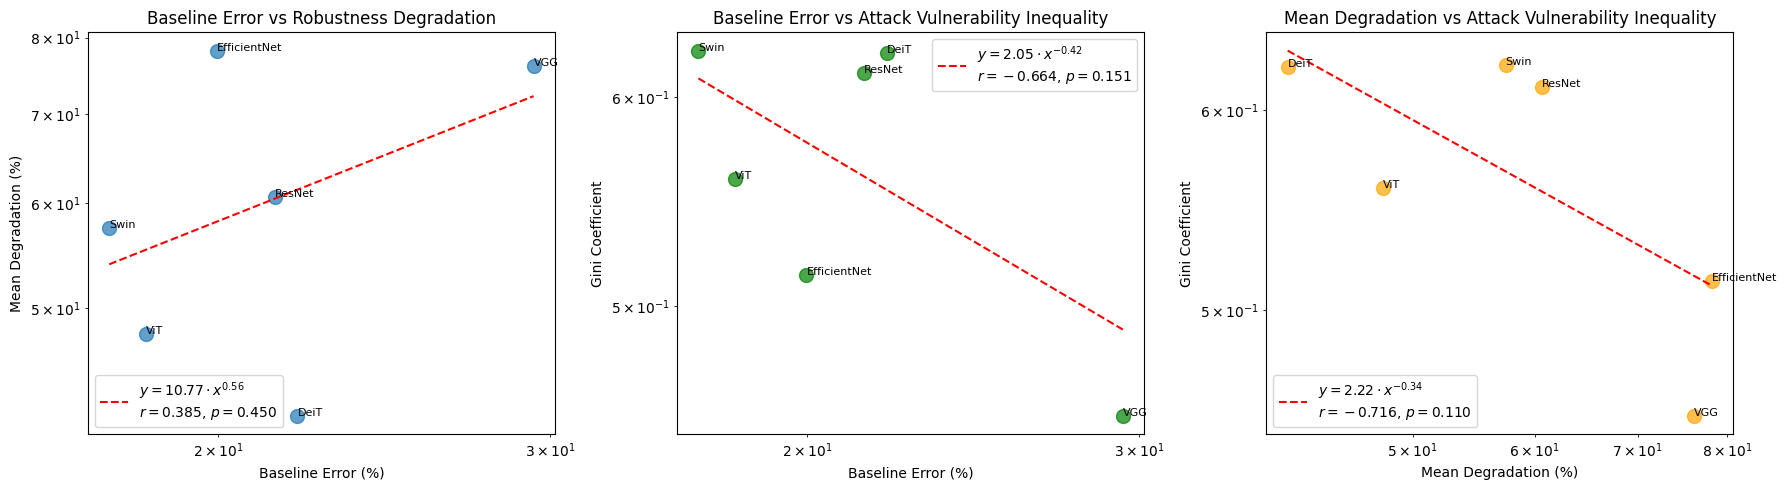


Power law fits:
1. Degradation = 10.766 * BaselineError^0.563 (r=0.385, p=0.4504)
2. Gini = 2.049 * BaselineError^-0.423 (r=-0.664, p=0.1505)
3. Gini = 2.224 * MeanDegradation^-0.337 (r=-0.716, p=0.1095)


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

# Power law function: y = a * x^b
def power_law(x, a, b):
    return a * np.power(x, b)

# Get baseline errors for each family
baseline_df = grouped_df.xs('baseline', level='attack')

# Get mean robustness degradation (average percentage change across all attacks)
pct_change_no_baseline = pct_change_sorted.drop('baseline', level='attack', errors='ignore')
# Extract column first, then group
mean_values = pct_change_no_baseline[('top1_err', 'mean')]
mean_degradation = mean_values.groupby(level='family').mean()

# Combine with baseline error and Gini
analysis_df = pd.DataFrame({
    'baseline_error': baseline_df[('top1_err', 'mean')],
    'mean_degradation': mean_degradation,
    'gini': gini_by_family
})

print("Analysis dataframe:")
print(analysis_df)
print("\n")

# 1. Power law: baseline error vs mean degradation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Baseline error vs mean degradation
x1 = analysis_df['baseline_error'].values
y1 = analysis_df['mean_degradation'].values

# Fit power law
popt1, _ = curve_fit(power_law, x1, y1, p0=[1, 1])
y1_fit = power_law(x1, *popt1)
r1, p1 = pearsonr(np.log(x1), np.log(y1))

axes[0].scatter(x1, y1, s=100, alpha=0.7)
x1_sorted = np.sort(x1)
axes[0].plot(x1_sorted, power_law(x1_sorted, *popt1), 'r--',
            label=f'$y = {popt1[0]:.2f} \\cdot x^{{{popt1[1]:.2f}}}$\n$r = {r1:.3f}$, $p = {p1:.3f}$')
for i, family in enumerate(analysis_df.index):
    axes[0].annotate(family, (x1[i], y1[i]), fontsize=8)
axes[0].set_xlabel('Baseline Error (%)')
axes[0].set_ylabel('Mean Degradation (%)')
axes[0].set_title('Baseline Error vs Robustness Degradation')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Plot 2: Baseline error vs Gini coefficient
x2 = analysis_df['baseline_error'].values
y2 = analysis_df['gini'].values

popt2, _ = curve_fit(power_law, x2, y2, p0=[1, -0.5])
y2_fit = power_law(x2, *popt2)
r2, p2 = pearsonr(np.log(x2), np.log(y2))

axes[1].scatter(x2, y2, s=100, alpha=0.7, color='green')
x2_sorted = np.sort(x2)
axes[1].plot(x2_sorted, power_law(x2_sorted, *popt2), 'r--',
            label=f'$y = {popt2[0]:.2f} \\cdot x^{{{popt2[1]:.2f}}}$\n$r = {r2:.3f}$, $p = {p2:.3f}$')
for i, family in enumerate(analysis_df.index):
    axes[1].annotate(family, (x2[i], y2[i]), fontsize=8)
axes[1].set_xlabel('Baseline Error (%)')
axes[1].set_ylabel('Gini Coefficient')
axes[1].set_title('Baseline Error vs Attack Vulnerability Inequality')
axes[1].legend()
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Plot 3: Mean degradation vs Gini coefficient
x3 = analysis_df['mean_degradation'].values
y3 = analysis_df['gini'].values

popt3, _ = curve_fit(power_law, x3, y3, p0=[1, -0.5])
y3_fit = power_law(x3, *popt3)
r3, p3 = pearsonr(np.log(x3), np.log(y3))

axes[2].scatter(x3, y3, s=100, alpha=0.7, color='orange')
x3_sorted = np.sort(x3)
axes[2].plot(x3_sorted, power_law(x3_sorted, *popt3), 'r--',
            label=f'$y = {popt3[0]:.2f} \\cdot x^{{{popt3[1]:.2f}}}$\n$r = {r3:.3f}$, $p = {p3:.3f}$')
for i, family in enumerate(analysis_df.index):
    axes[2].annotate(family, (x3[i], y3[i]), fontsize=8)
axes[2].set_xlabel('Mean Degradation (%)')
axes[2].set_ylabel('Gini Coefficient')
axes[2].set_title('Mean Degradation vs Attack Vulnerability Inequality')
axes[2].legend()
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_law_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPower law fits:")
print(f"1. Degradation = {popt1[0]:.3f} * BaselineError^{popt1[1]:.3f} (r={r1:.3f}, p={p1:.4f})")
print(f"2. Gini = {popt2[0]:.3f} * BaselineError^{popt2[1]:.3f} (r={r2:.3f}, p={p2:.4f})")
print(f"3. Gini = {popt3[0]:.3f} * MeanDegradation^{popt3[1]:.3f} (r={r3:.3f}, p={p3:.4f})")


In [46]:
df.to_csv("combined_results.csv", index=False)

Individual model analysis (first 10 rows):
                      model_name        family  baseline_error  \
0          vit_large_patch16_224           ViT          14.234   
1           vit_base_patch16_224           ViT          15.632   
2   swin_base_patch4_window7_224          Swin          16.660   
3             tf_efficientnet_b5  EfficientNet          16.942   
4  swin_small_patch4_window7_224          Swin          17.024   
5             tf_efficientnet_b4  EfficientNet          17.604   
6                      resnet101        ResNet          17.812   
7          deit_base_patch16_224          DeiT          18.062   
8   swin_tiny_patch4_window7_224          Swin          18.844   
9          vit_small_patch16_224           ViT          18.848   

   mean_degradation      gini  
0         34.699390  0.584921  
1         42.218242  0.580391  
2         57.851140  0.628090  
3         80.805100  0.558118  
4         56.156015  0.627429  
5         81.656947  0.523633  
6     

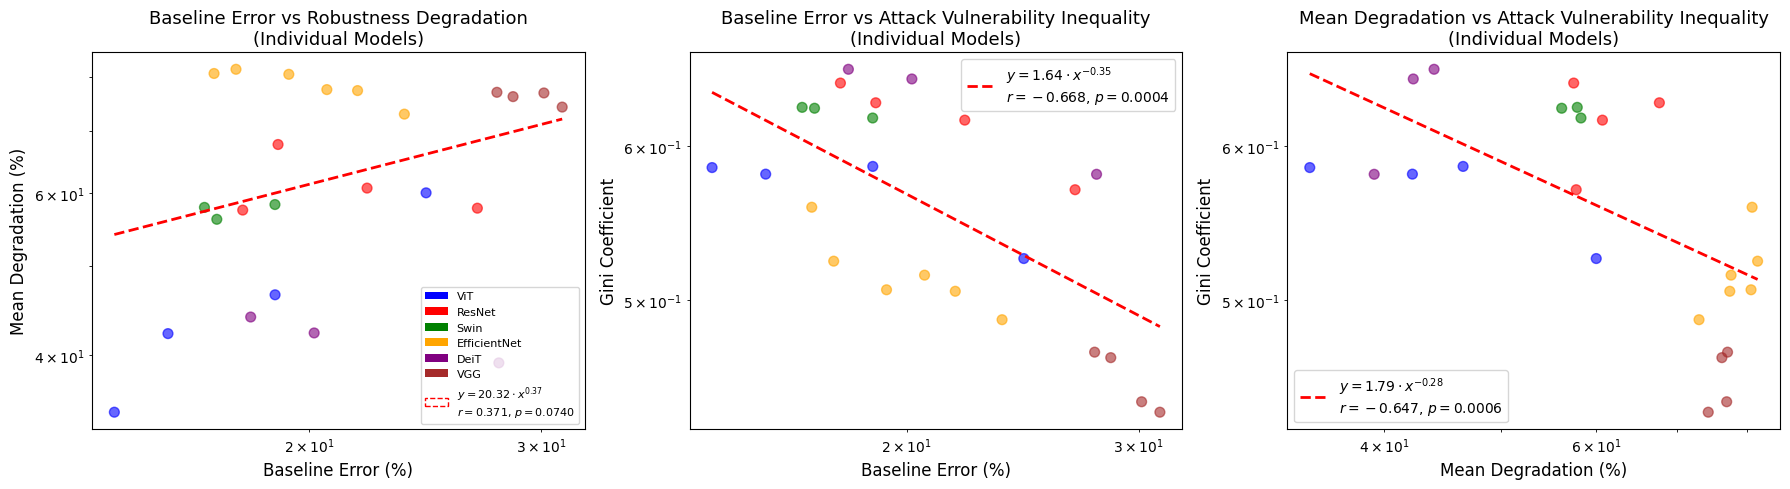


POWER LAW ANALYSIS RESULTS (Individual Models)

1. Baseline Error → Robustness Degradation
   Formula: Degradation = 20.324 × BaselineError^0.368
   Correlation: r = 0.371, p = 0.0740
   Interpretation: Sub-linear (b=0.37): Worse models degrade more, but not proportionally

2. Baseline Error → Vulnerability Inequality (Gini)
   Formula: Gini = 1.637 × BaselineError^-0.354
   Correlation: r = -0.668, p = 0.0004
   Interpretation: Negative (b=-0.35): Better models have MORE concentrated vulnerabilities

3. Mean Degradation → Vulnerability Inequality (Gini)
   Formula: Gini = 1.792 × MeanDegradation^-0.284
   Correlation: r = -0.647, p = 0.0006
   Interpretation: Negative (b=-0.28): Models that degrade more have UNIFORM vulnerabilities


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr

df = pd.read_csv("combined_results.csv")

def gini_coefficient(x):
    """Calculate Gini coefficient for an array of values."""
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    sorted_x = np.sort(x)
    n = len(sorted_x)
    cumsum = np.cumsum(sorted_x)
    gini = (2 * np.sum((np.arange(1, n + 1)) * sorted_x)) / (n * cumsum[-1]) - (n + 1) / n
    return gini

def power_law(x, a, b):
    return a * np.power(x, b)

# Get baseline values for each model
baseline_models = df[df['attack'] == 'baseline'][['model_name', 'family', 'top1_err']].copy()
baseline_models.rename(columns={'top1_err': 'baseline_error'}, inplace=True)

# For each model, calculate percentage change from its baseline for each attack
model_analysis = []

for model_name in baseline_models['model_name'].unique():
    model_data = df[df['model_name'] == model_name].copy()
    baseline_err = model_data[model_data['attack'] == 'baseline']['top1_err'].values[0]
    family = model_data['family'].iloc[0]

    # Get all non-baseline attacks
    attack_data = model_data[model_data['attack'] != 'baseline'].copy()

    if len(attack_data) == 0:
        continue

    # Calculate percentage change for each attack
    pct_changes = ((attack_data['top1_err'] - baseline_err) / baseline_err * 100).values

    # Calculate mean degradation and Gini
    mean_degradation = np.mean(pct_changes)
    gini = gini_coefficient(pct_changes)

    model_analysis.append({
        'model_name': model_name,
        'family': family,
        'baseline_error': baseline_err,
        'mean_degradation': mean_degradation,
        'gini': gini
    })

# Create analysis dataframe
individual_analysis_df = pd.DataFrame(model_analysis)

print("Individual model analysis (first 10 rows):")
print(individual_analysis_df.head(10))
print(f"\nTotal models analyzed: {len(individual_analysis_df)}")
print("\nSummary statistics:")
print(individual_analysis_df.describe())

# Power law analysis on individual models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Color map for families
family_colors = {
    'ViT': 'blue',
    'ResNet': 'red',
    'Swin': 'green',
    'EfficientNet': 'orange',
    'DeiT': 'purple',
    'VGG': 'brown'
}

# Plot 1: Baseline error vs mean degradation
x1 = individual_analysis_df['baseline_error'].values
y1 = individual_analysis_df['mean_degradation'].values
colors1 = [family_colors.get(f, 'gray') for f in individual_analysis_df['family']]

popt1, _ = curve_fit(power_law, x1, y1, p0=[1, 1])
r1, p1 = pearsonr(np.log(x1), np.log(y1))

axes[0].scatter(x1, y1, s=50, alpha=0.6, c=colors1)
x1_sorted = np.sort(x1)
axes[0].plot(x1_sorted, power_law(x1_sorted, *popt1), 'r--', linewidth=2,
            label=f'$y = {popt1[0]:.2f} \\cdot x^{{{popt1[1]:.2f}}}$\n$r = {r1:.3f}$, $p = {p1:.4f}$')
axes[0].set_xlabel('Baseline Error (%)', fontsize=12)
axes[0].set_ylabel('Mean Degradation (%)', fontsize=12)
axes[0].set_title('Baseline Error vs Robustness Degradation\n(Individual Models)', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

# Add legend for families
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=family) for family, color in family_colors.items()]
axes[0].legend(handles=legend_elements + [Patch(facecolor='none', edgecolor='red', linestyle='--', label=f'$y = {popt1[0]:.2f} \\cdot x^{{{popt1[1]:.2f}}}$\n$r = {r1:.3f}$, $p = {p1:.4f}$')],
                fontsize=8, loc='best')

# Plot 2: Baseline error vs Gini coefficient
x2 = individual_analysis_df['baseline_error'].values
y2 = individual_analysis_df['gini'].values
colors2 = [family_colors.get(f, 'gray') for f in individual_analysis_df['family']]

popt2, _ = curve_fit(power_law, x2, y2, p0=[1, -0.5])
r2, p2 = pearsonr(np.log(x2), np.log(y2))

axes[1].scatter(x2, y2, s=50, alpha=0.6, c=colors2)
x2_sorted = np.sort(x2)
axes[1].plot(x2_sorted, power_law(x2_sorted, *popt2), 'r--', linewidth=2,
            label=f'$y = {popt2[0]:.2f} \\cdot x^{{{popt2[1]:.2f}}}$\n$r = {r2:.3f}$, $p = {p2:.4f}$')
axes[1].set_xlabel('Baseline Error (%)', fontsize=12)
axes[1].set_ylabel('Gini Coefficient', fontsize=12)
axes[1].set_title('Baseline Error vs Attack Vulnerability Inequality\n(Individual Models)', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

# Plot 3: Mean degradation vs Gini coefficient
x3 = individual_analysis_df['mean_degradation'].values
y3 = individual_analysis_df['gini'].values
colors3 = [family_colors.get(f, 'gray') for f in individual_analysis_df['family']]

popt3, _ = curve_fit(power_law, x3, y3, p0=[1, -0.5])
r3, p3 = pearsonr(np.log(x3), np.log(y3))

axes[2].scatter(x3, y3, s=50, alpha=0.6, c=colors3)
x3_sorted = np.sort(x3)
axes[2].plot(x3_sorted, power_law(x3_sorted, *popt3), 'r--', linewidth=2,
            label=f'$y = {popt3[0]:.2f} \\cdot x^{{{popt3[1]:.2f}}}$\n$r = {r3:.3f}$, $p = {p3:.4f}$')
axes[2].set_xlabel('Mean Degradation (%)', fontsize=12)
axes[2].set_ylabel('Gini Coefficient', fontsize=12)
axes[2].set_title('Mean Degradation vs Attack Vulnerability Inequality\n(Individual Models)', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_law_analysis_individual.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("POWER LAW ANALYSIS RESULTS (Individual Models)")
print("="*70)
print(f"\n1. Baseline Error → Robustness Degradation")
print(f"   Formula: Degradation = {popt1[0]:.3f} × BaselineError^{popt1[1]:.3f}")
print(f"   Correlation: r = {r1:.3f}, p = {p1:.4f}")
print(f"   Interpretation: ", end="")
if popt1[1] > 1:
    print(f"Super-linear (b={popt1[1]:.2f}): Worse models degrade MUCH more")
elif popt1[1] > 0:
    print(f"Sub-linear (b={popt1[1]:.2f}): Worse models degrade more, but not proportionally")
else:
    print(f"Negative (b={popt1[1]:.2f}): Worse models are relatively MORE robust!")

print(f"\n2. Baseline Error → Vulnerability Inequality (Gini)")
print(f"   Formula: Gini = {popt2[0]:.3f} × BaselineError^{popt2[1]:.3f}")
print(f"   Correlation: r = {r2:.3f}, p = {p2:.4f}")
print(f"   Interpretation: ", end="")
if popt2[1] < 0:
    print(f"Negative (b={popt2[1]:.2f}): Better models have MORE concentrated vulnerabilities")
else:
    print(f"Positive (b={popt2[1]:.2f}): Worse models have MORE concentrated vulnerabilities")

print(f"\n3. Mean Degradation → Vulnerability Inequality (Gini)")
print(f"   Formula: Gini = {popt3[0]:.3f} × MeanDegradation^{popt3[1]:.3f}")
print(f"   Correlation: r = {r3:.3f}, p = {p3:.4f}")
print(f"   Interpretation: ", end="")
if popt3[1] < 0:
    print(f"Negative (b={popt3[1]:.2f}): Models that degrade more have UNIFORM vulnerabilities")
else:
    print(f"Positive (b={popt3[1]:.2f}): Models that degrade more have CONCENTRATED vulnerabilities")
print("="*70)